In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('iris.csv')

In [4]:
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [6]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [7]:
df['variety'] = encoder.fit_transform(df['variety'])

In [8]:
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [10]:
df.drop(columns=['sepal.width' , 'petal.length'] , inplace=True)

In [12]:
df = df[df['variety']!=0]

In [13]:
df

,sepal.length,petal.width,variety
50,7.0,1.4,1
51,6.4,1.5,1
52,6.9,1.5,1
53,5.5,1.3,1
54,6.5,1.5,1
...,...,...,...
145,6.7,2.3,2
146,6.3,1.9,2
147,6.5,2.0,2
148,6.2,2.3,2


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

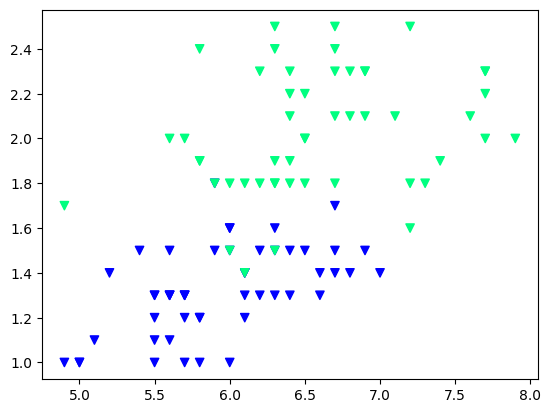

In [22]:
plt.scatter(df['sepal.length'] , df['petal.width'] ,c = df['variety'] , cmap = 'winter' , marker='v')

In [25]:
#Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60 ,:].sample(10)
df_val = df.iloc[60:80 , :].sample(5)
df_test = df.iloc[80:, :].sample(5)

In [26]:
X_test = df_val.iloc[: , 0:2]
y_test = df_val.iloc[: , -1]

In [31]:
df_bag = df_train.sample(8 , replace=True)
# replace => that means baar baar utha rahe hai daal de rahe possible ki ek hii row saari rows se aa rahi hoo 

X = df_bag.iloc[: , 0:2]
y = df_bag.iloc[: , -1]

In [32]:
df_bag

,sepal.length,petal.width,variety
50,7.0,1.4,1
90,5.5,1.2,1
90,5.5,1.2,1
54,6.5,1.5,1
50,7.0,1.4,1
53,5.5,1.3,1
113,5.7,2.0,2
54,6.5,1.5,1


In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions

In [34]:
dt_bag1 = DecisionTreeClassifier() # Max_depth is not specified so by default None

In [44]:
def evaluate(clf , X , y):
    clf.fit(X , y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values , clf = clf , legend=2)
    y_pred = clf.predict(X_test)
    print("accuracy_score" , accuracy_score(y_test , y_pred))

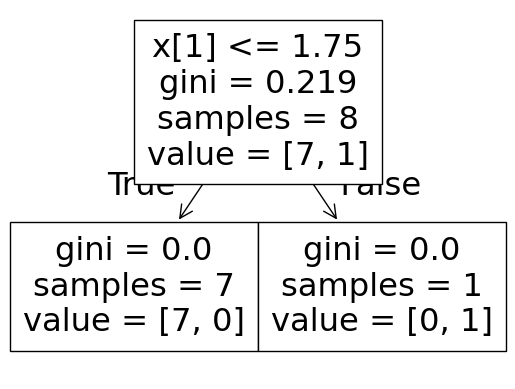

/home/sudhanshu-jain/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


accuracy_score 1.0


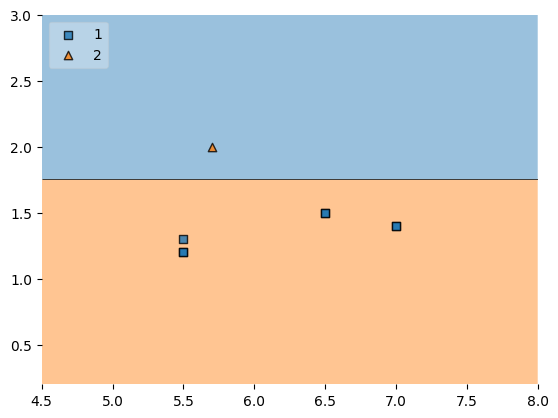

In [45]:
evaluate(dt_bag1 , X , y)

<!-- 2 same work for 2 times more  -->

In [51]:
df_bag = df_train.sample(8 , replace=True)
# replace => that means baar baar utha rahe hai daal de rahe possible ki ek hii row saari rows se aa rahi hoo 

X = df_bag.iloc[: , 0:2]
y = df_bag.iloc[: , -1]

In [52]:
dt_bag2 = DecisionTreeClassifier()

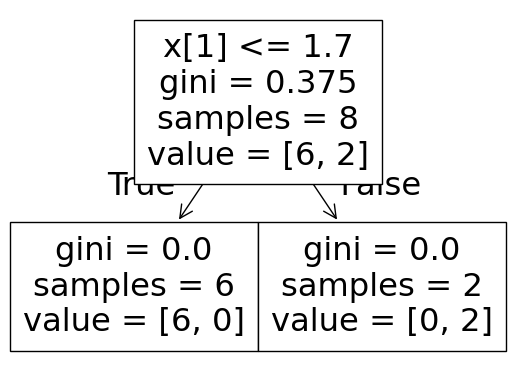

accuracy_score 1.0


/home/sudhanshu-jain/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


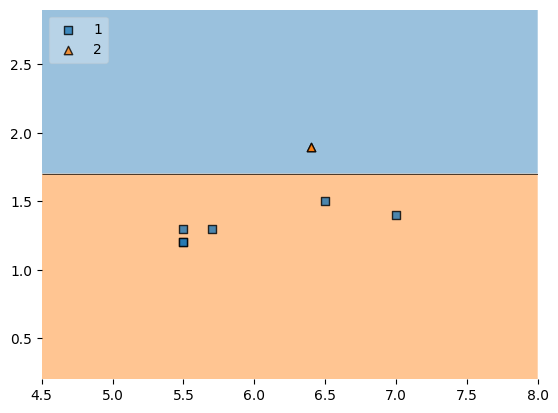

In [53]:
evaluate(dt_bag2 , X , y)

### Pasting 
But it is without replacement 

We have another option of sampling instead of do row sampling we do column sampling 

### Random Subspaces 

### Random Patches 

Both column sampleing as well as Row sampling 

Out motive is to give different data to the DecisionTreeClassifier() and this we can do by different mathods above 